In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"D:\Ultimate Programming\Data Bases\Machine Learning Datasets\Country-data.csv")
df.head(3)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460


In [3]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [4]:
df.shape

(167, 10)

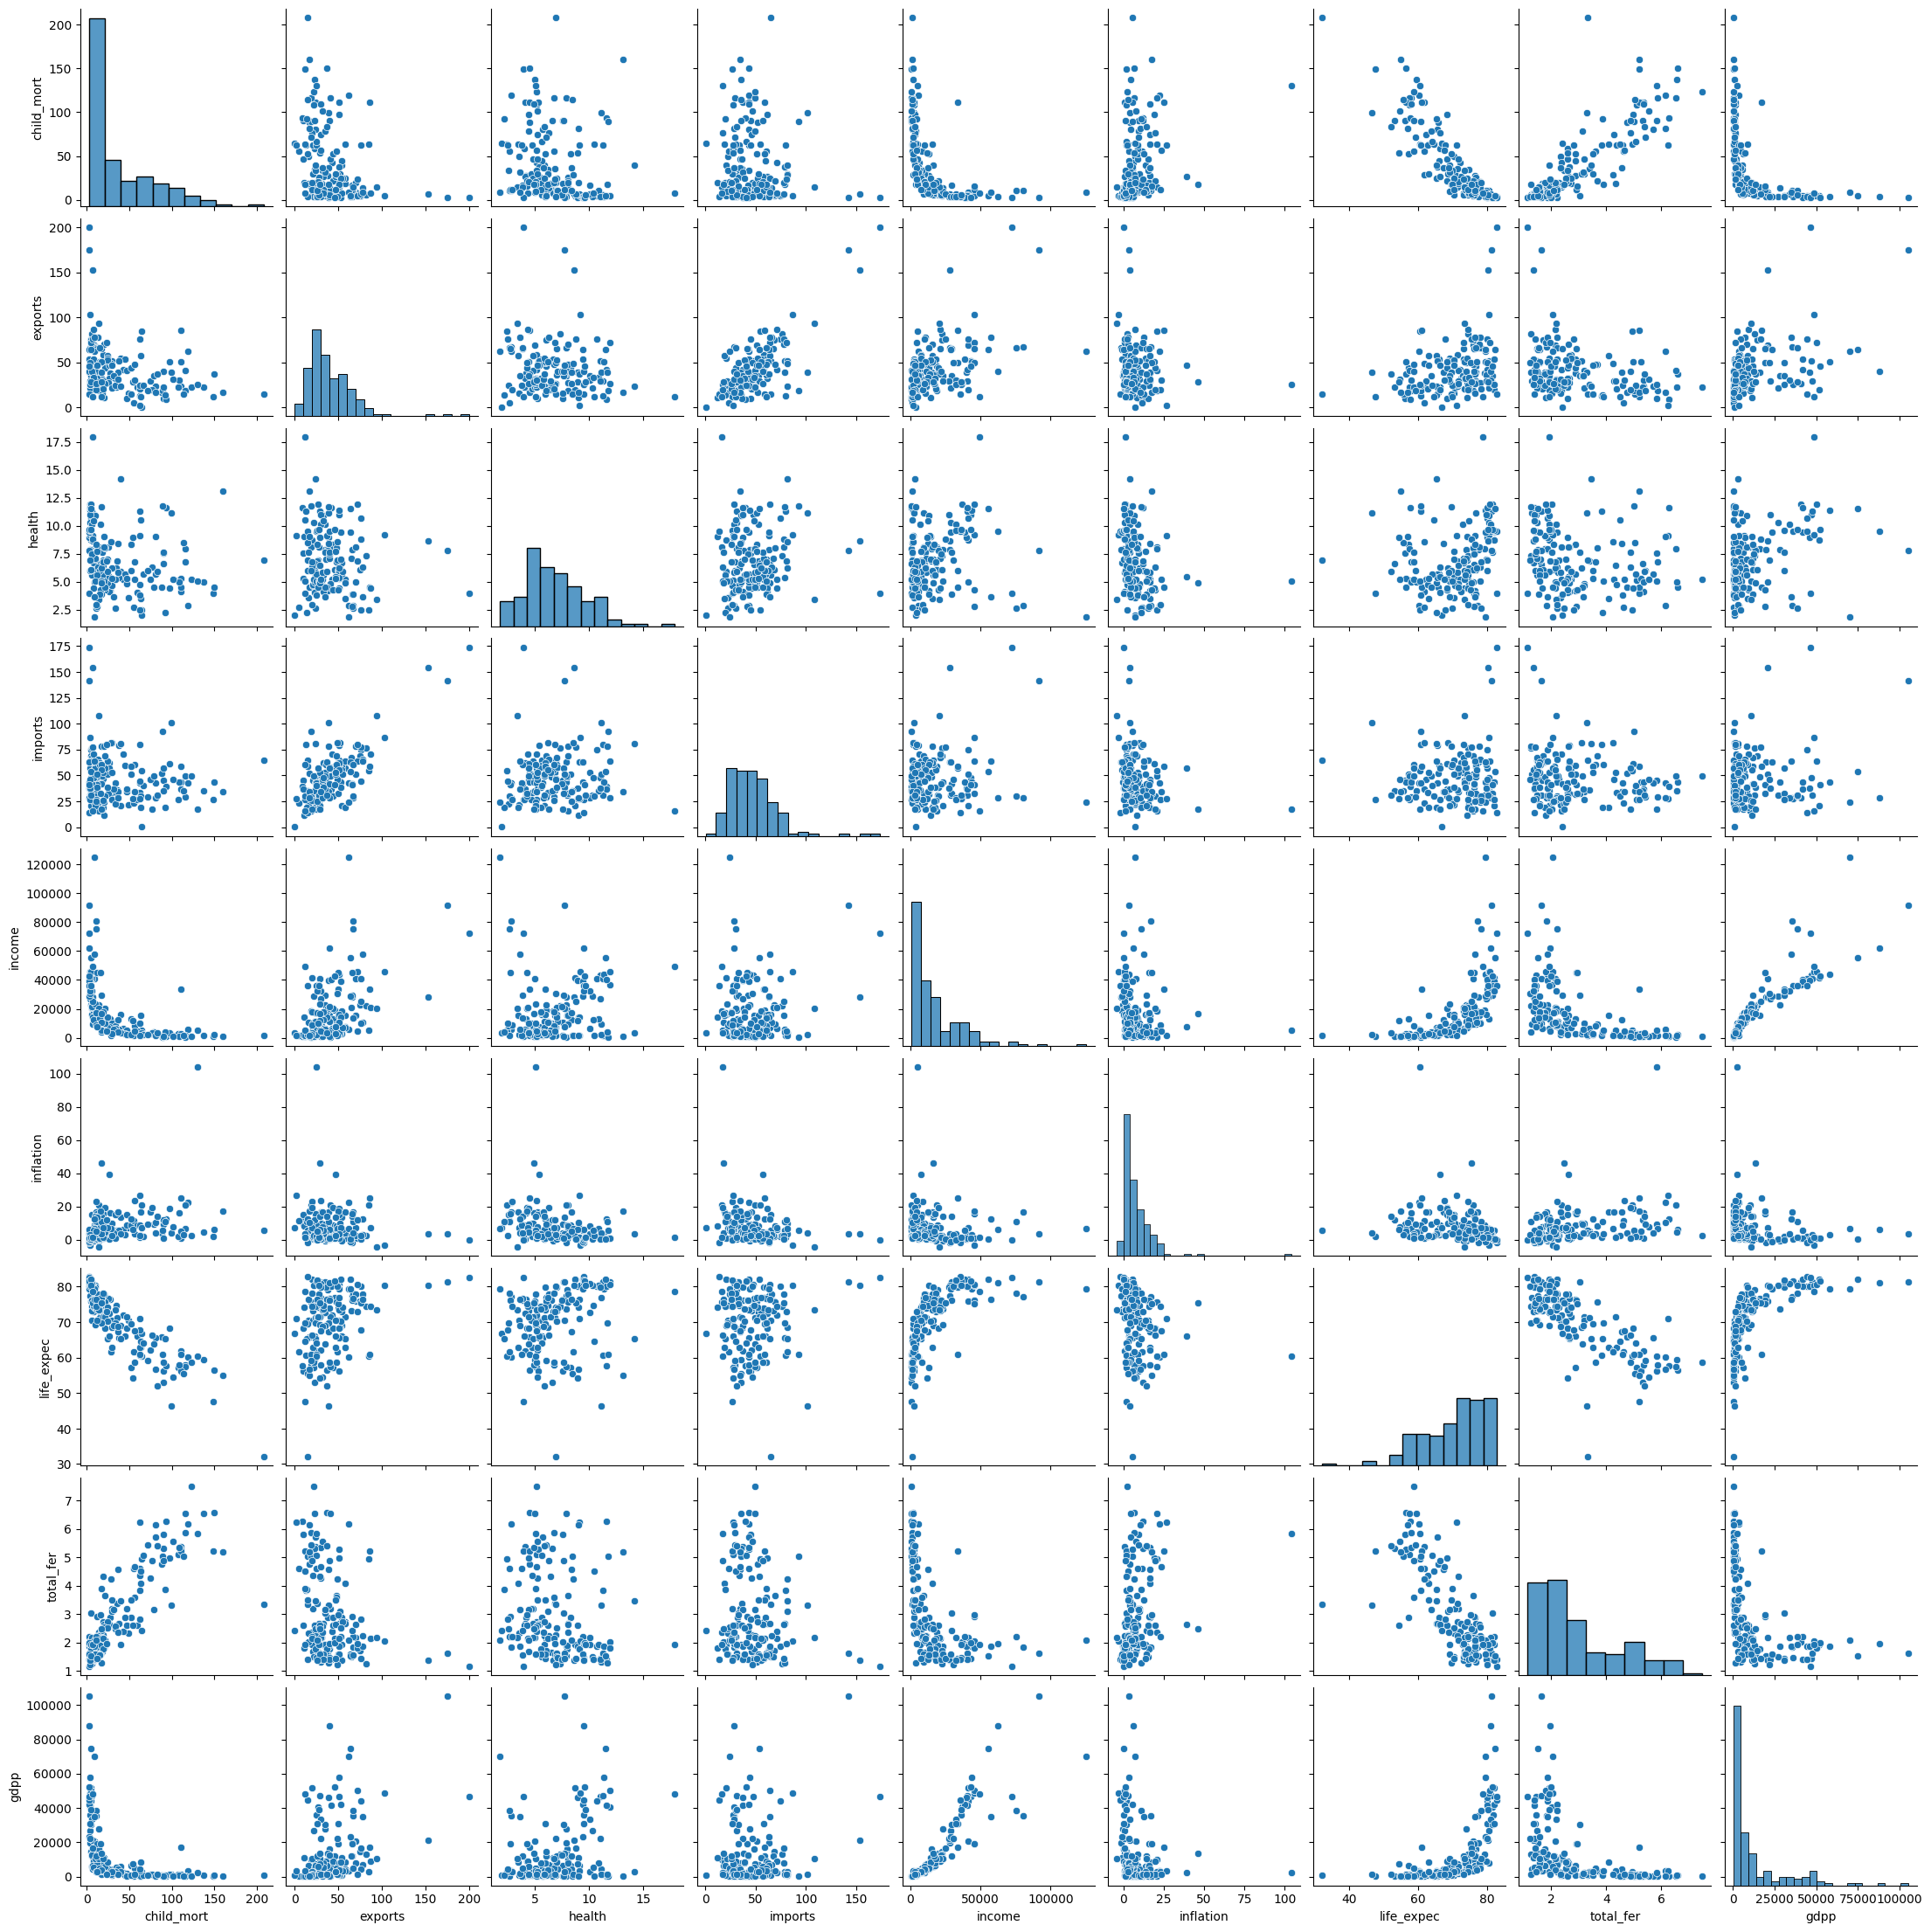

In [5]:
sns.pairplot(data=df.drop('country', axis=1))

In [6]:
x = df.drop('country', axis=1)

In [7]:
x.head(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090


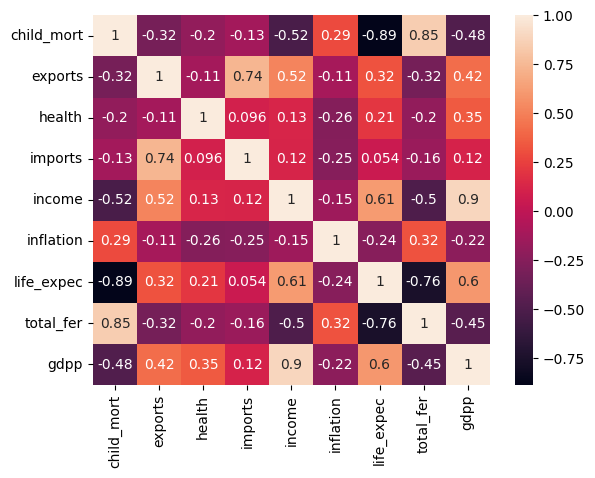

In [8]:
sns.heatmap(x.corr(), annot=True)
plt.show()

In [9]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

# **K-Means Clustering**

In [10]:
km = KMeans(n_clusters=2, init='k-means++')
km.fit(x)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [11]:
x['tar'] = km.fit_predict(x)

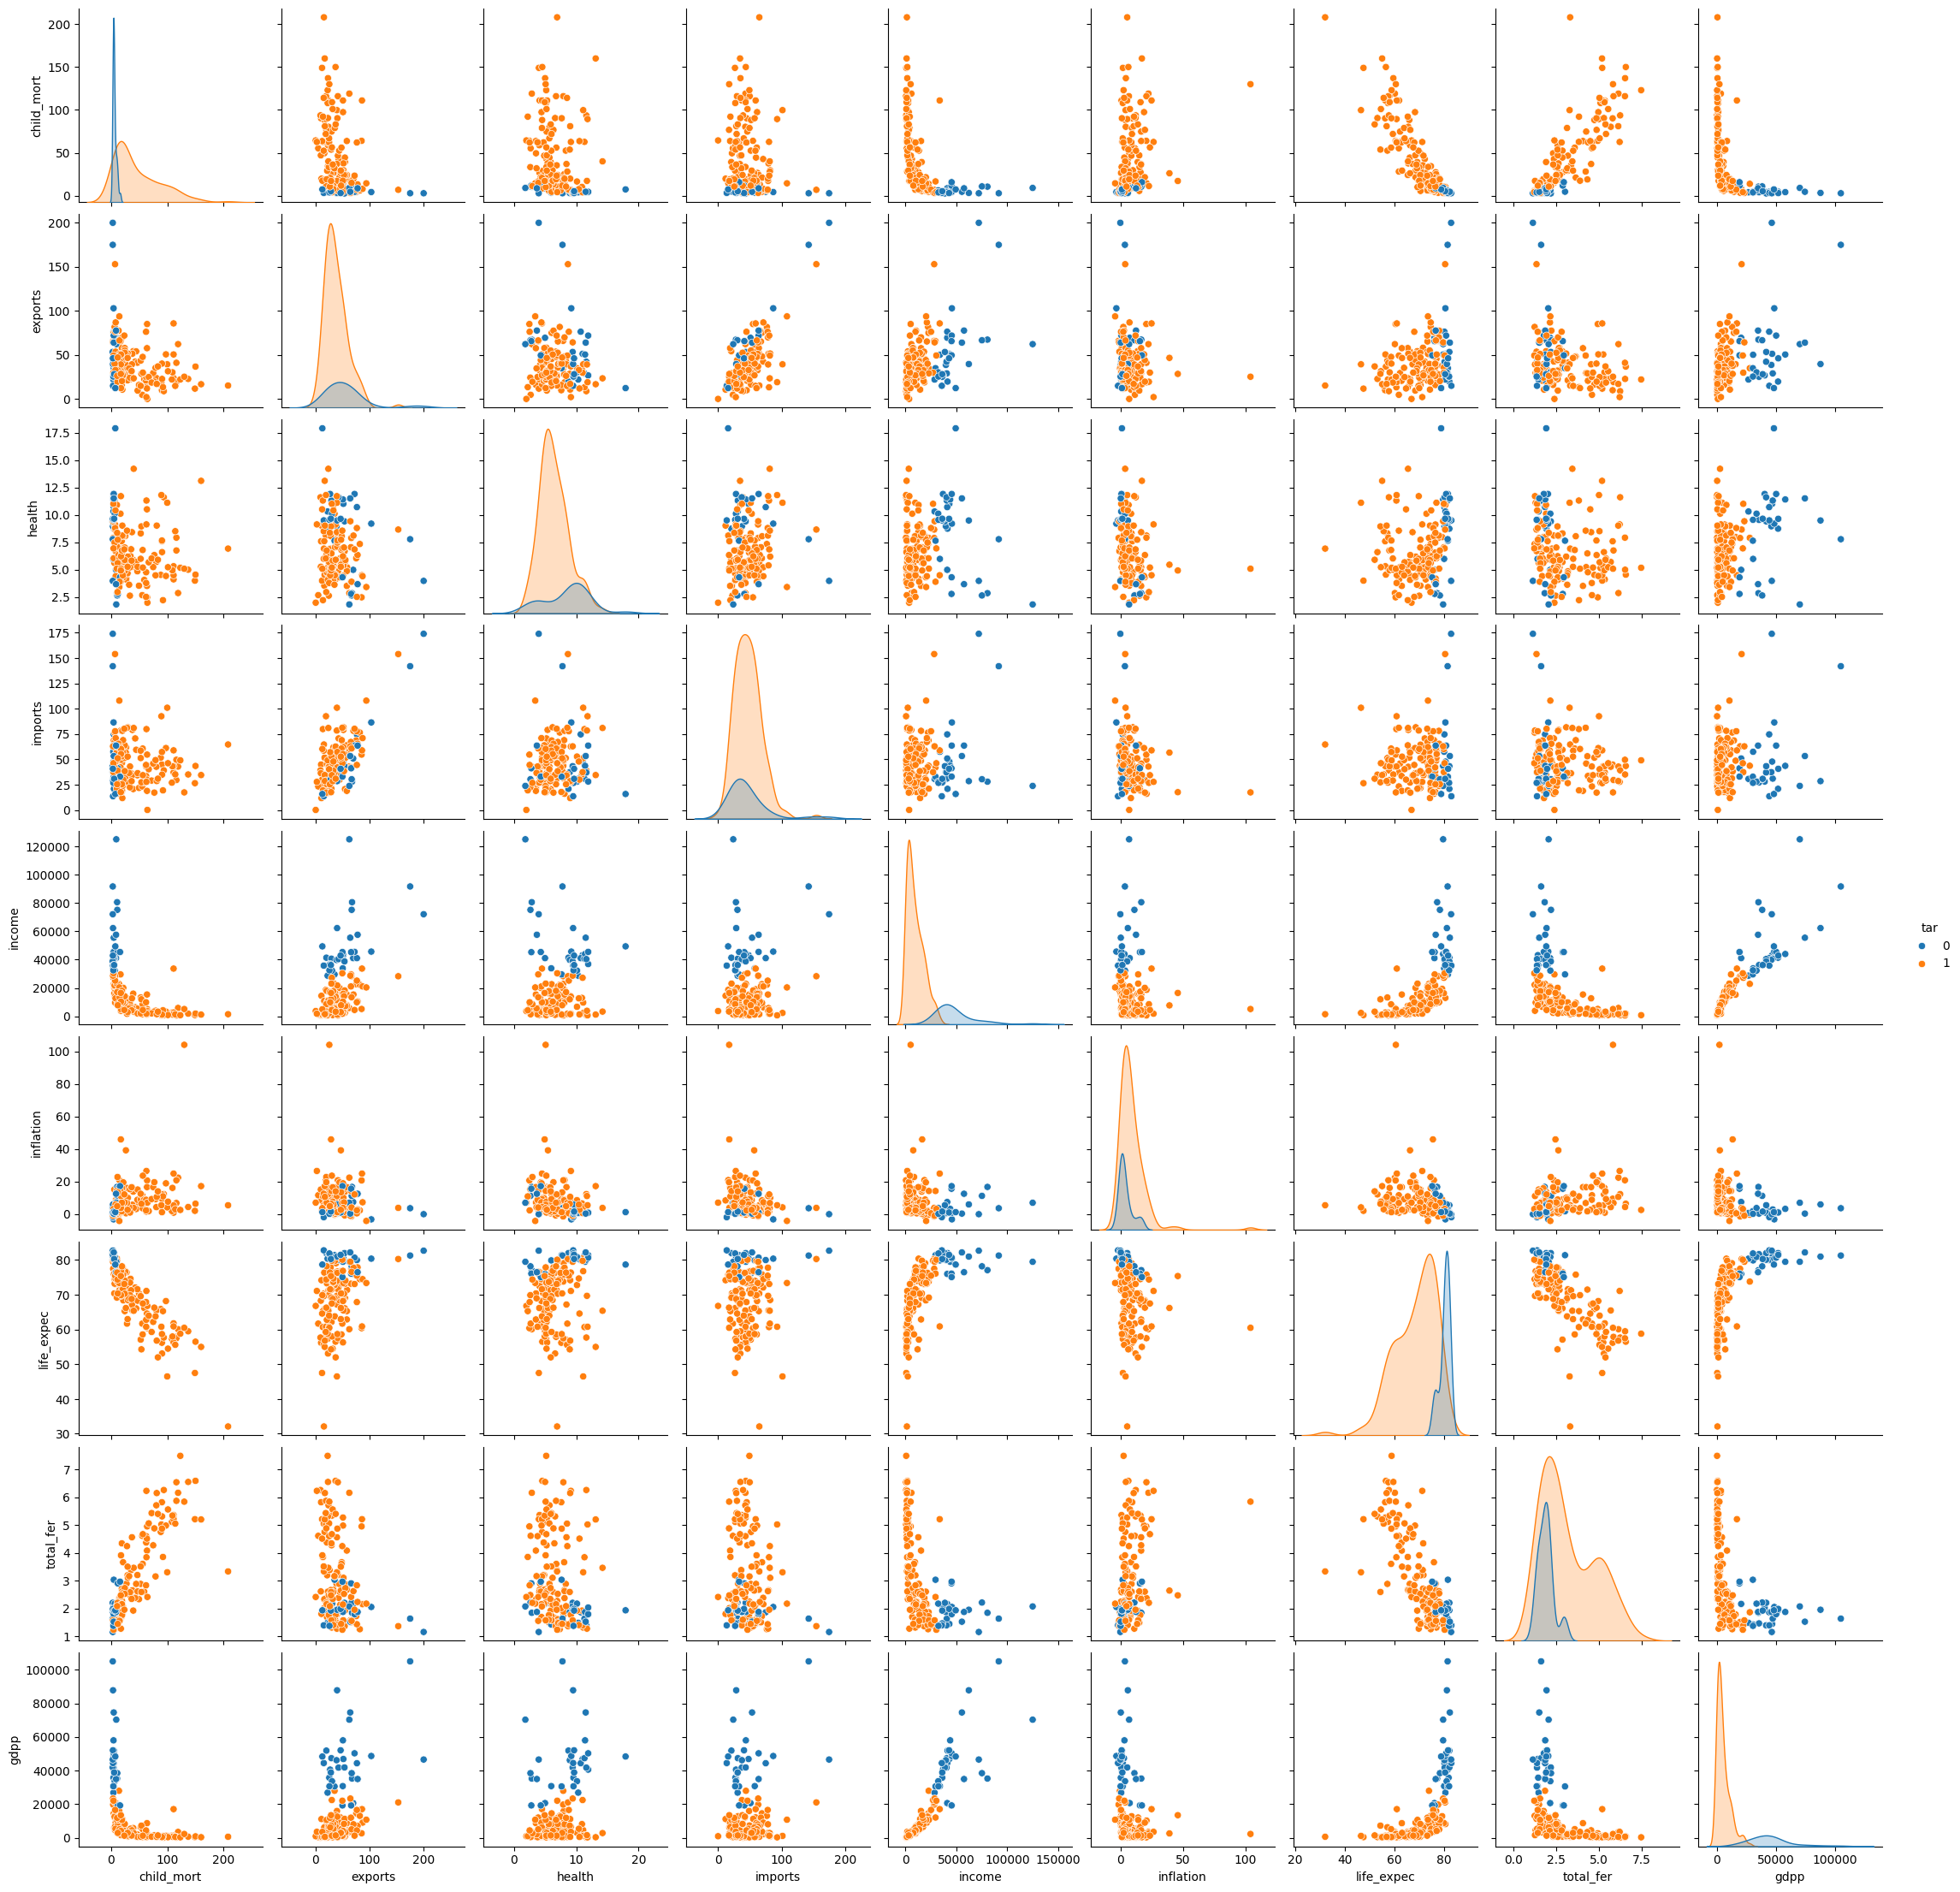

In [12]:
sns.pairplot(x, hue='tar')
plt.show()

In [13]:
x = x.drop('tar', axis=1)

In [14]:
wcss = []
clusters = [i for i in range(2,15)]
for i in range(2,15):
    km1 = KMeans(n_clusters=i, init='k-means++')
    km1.fit(x)
    wcss.append(km1.inertia_)

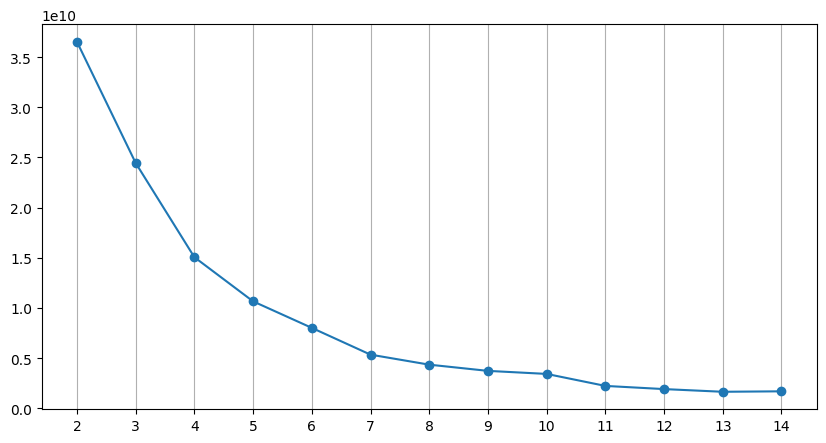

In [15]:
plt.figure(figsize=(10,5))
plt.plot(clusters, wcss, marker='o')
plt.xticks(clusters)
plt.grid(axis='x')
plt.show()

In [16]:
ss = []
for i in range(2, 15):
    km2 = KMeans(n_clusters=i, init='k-means++')
    km2.fit(x)
    ss.append(silhouette_score(x, km2.labels_))

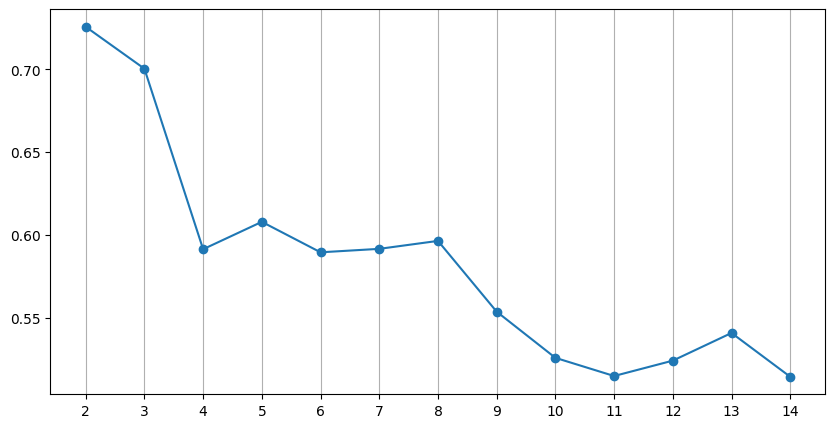

In [17]:
plt.figure(figsize=(10,5))
plt.plot(clusters, ss, marker='o')
plt.xticks(clusters)
plt.grid(axis='x')
plt.show()

# **Hierarchical Clustering**

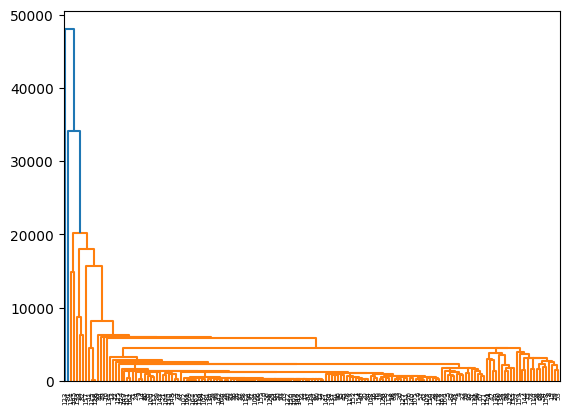

In [18]:
import scipy.cluster.hierarchy as sc
sc.dendrogram(sc.linkage(x, method='single'))
plt.show()

In [19]:
ac = AgglomerativeClustering(n_clusters=2, linkage='ward')
ac.fit(x)
x['tar'] = ac.fit_predict(x)

In [20]:
x.head(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,tar
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0


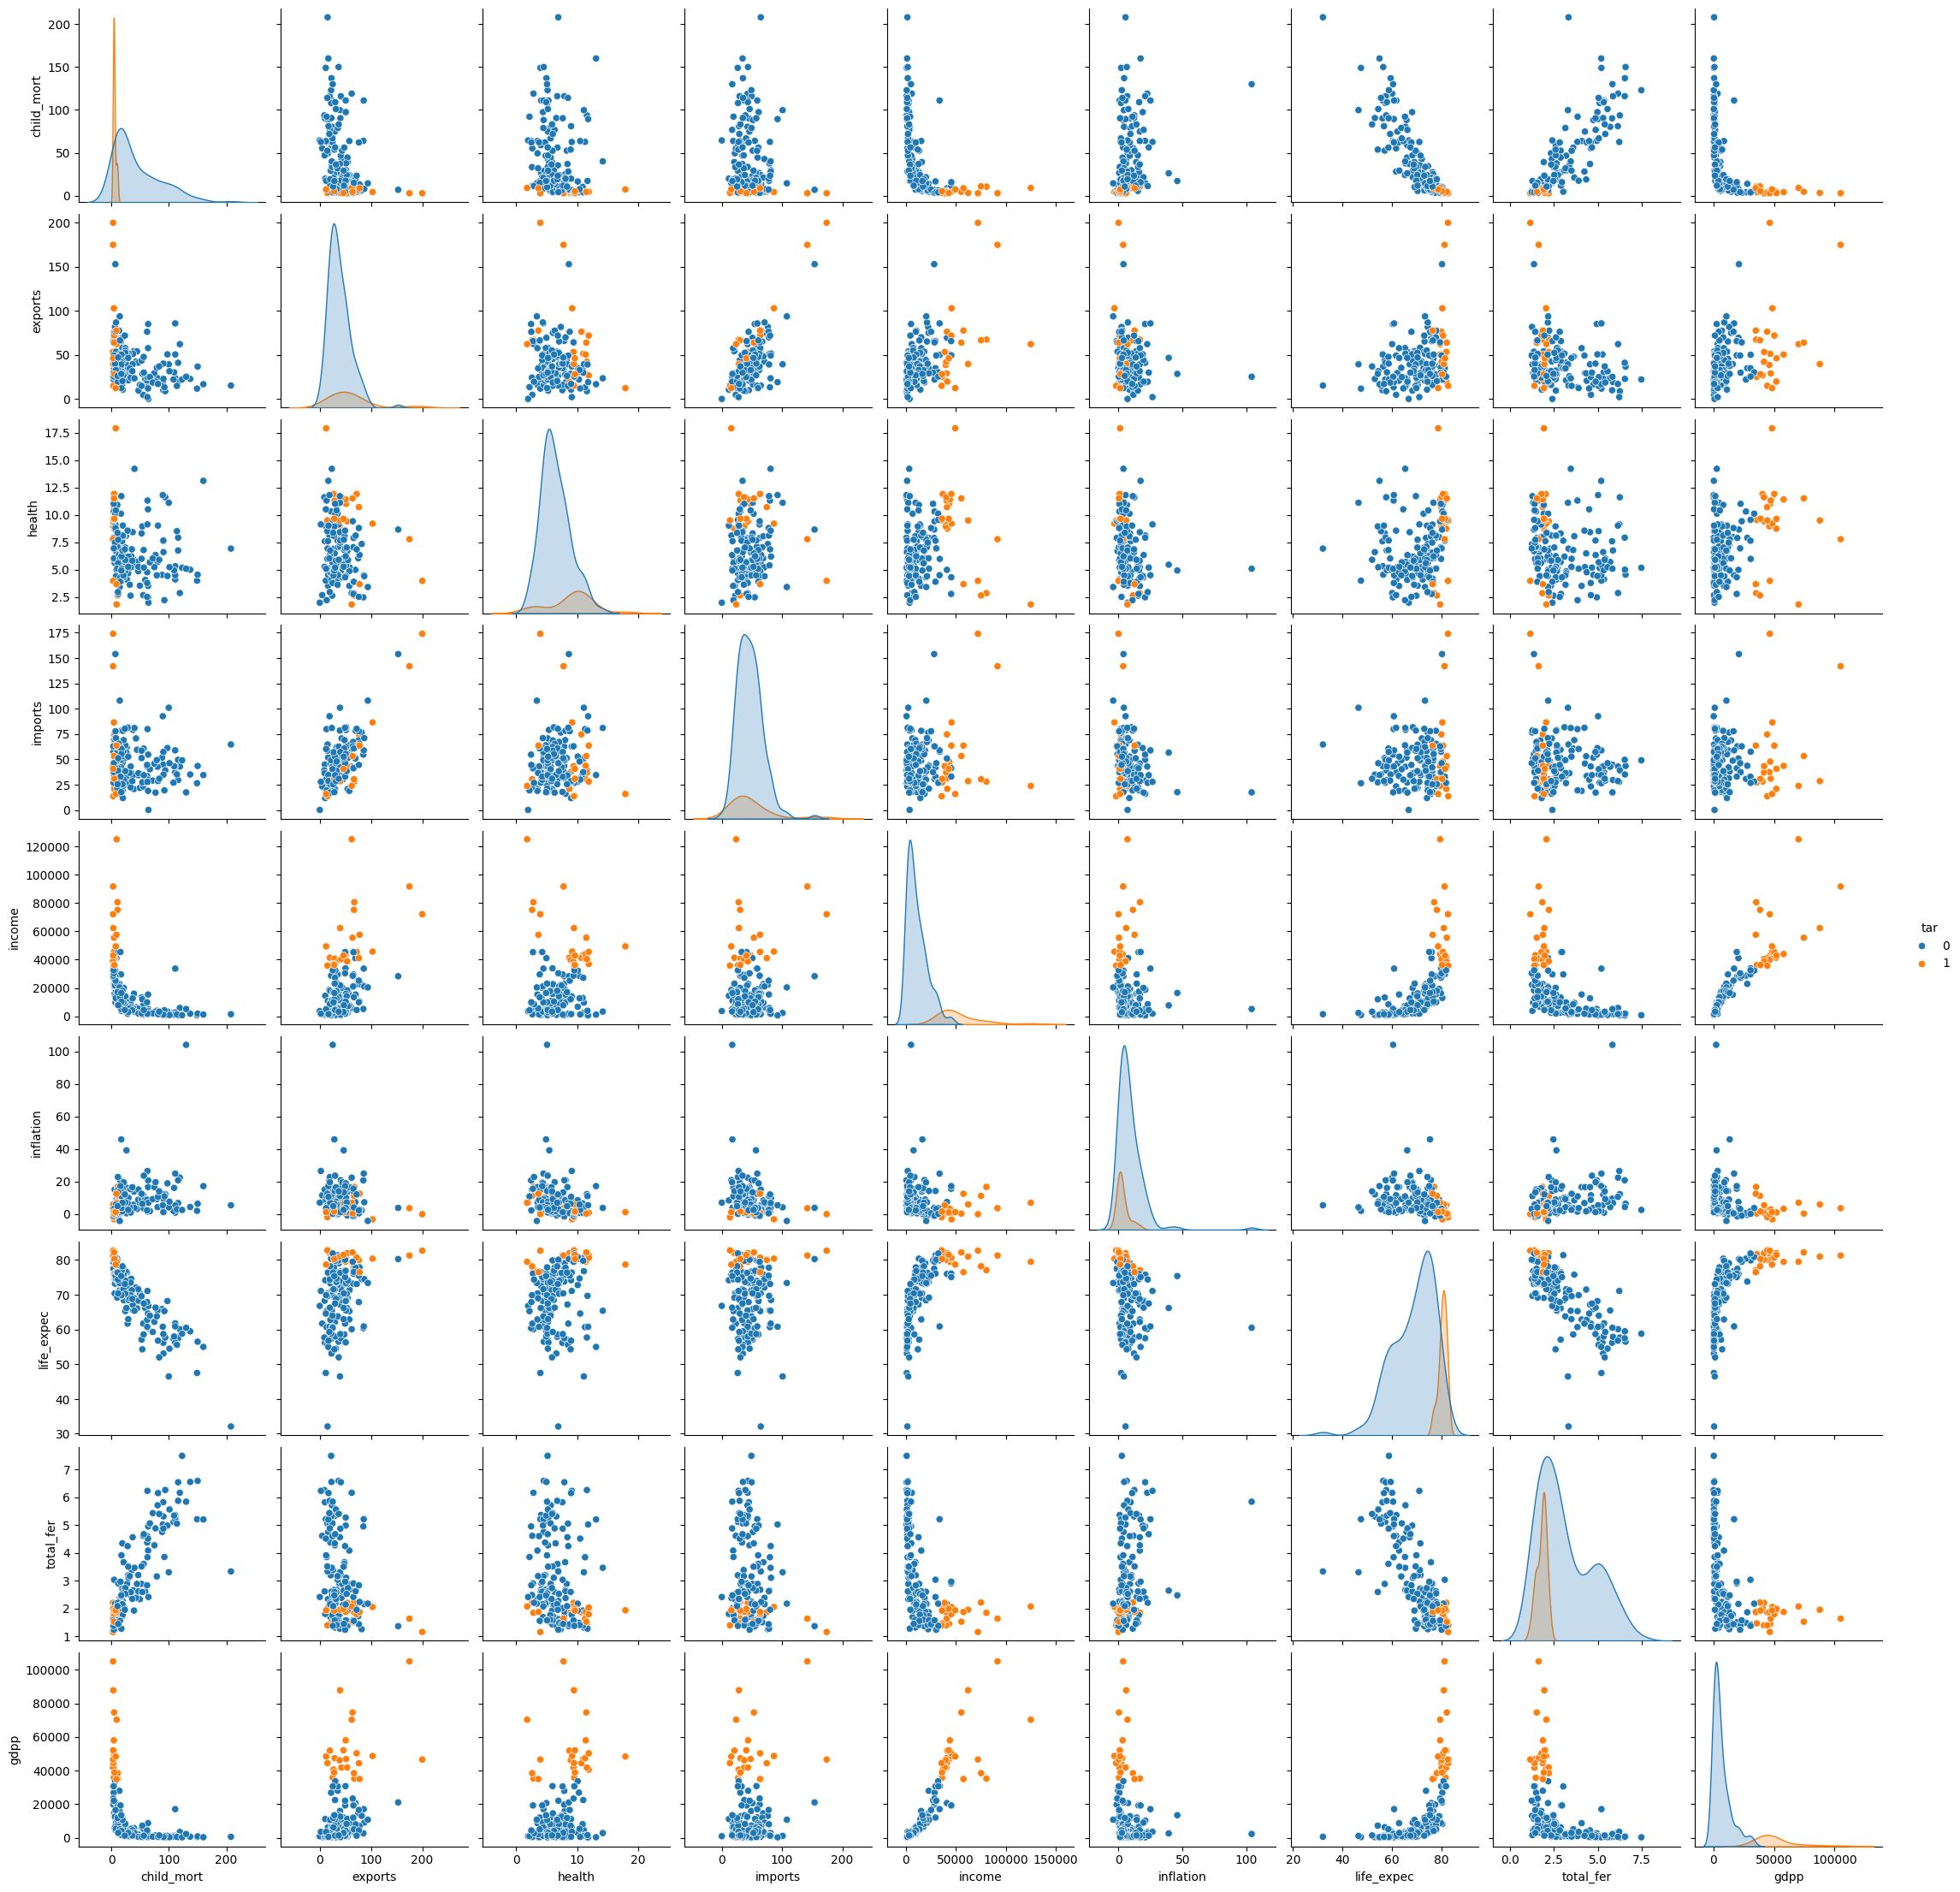

In [21]:
sns.pairplot(x, hue='tar')
plt.show()

In [22]:
x = x.drop('tar', axis=1)

In [24]:
ss = []
for i in range(2, 15):
    ag1 = AgglomerativeClustering(n_clusters=i, linkage='complete')
    ag1.fit(x)
    ss.append(silhouette_score(x, ag1.labels_))

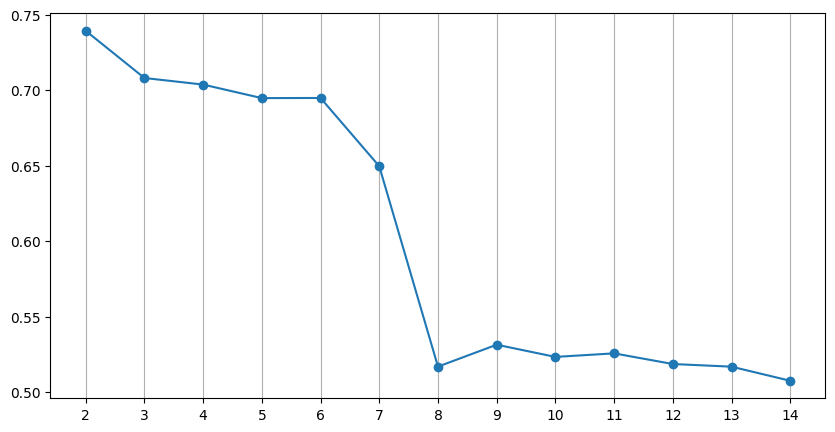

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(clusters, ss, marker='o')
plt.xticks(clusters)
plt.grid(axis='x')
plt.show()

In [29]:
x.head(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090


# **DBSCAN Clustering**

In [34]:
db = DBSCAN(eps=0.5)
db.fit(x)
x['tar'] = db.fit_predict(x)

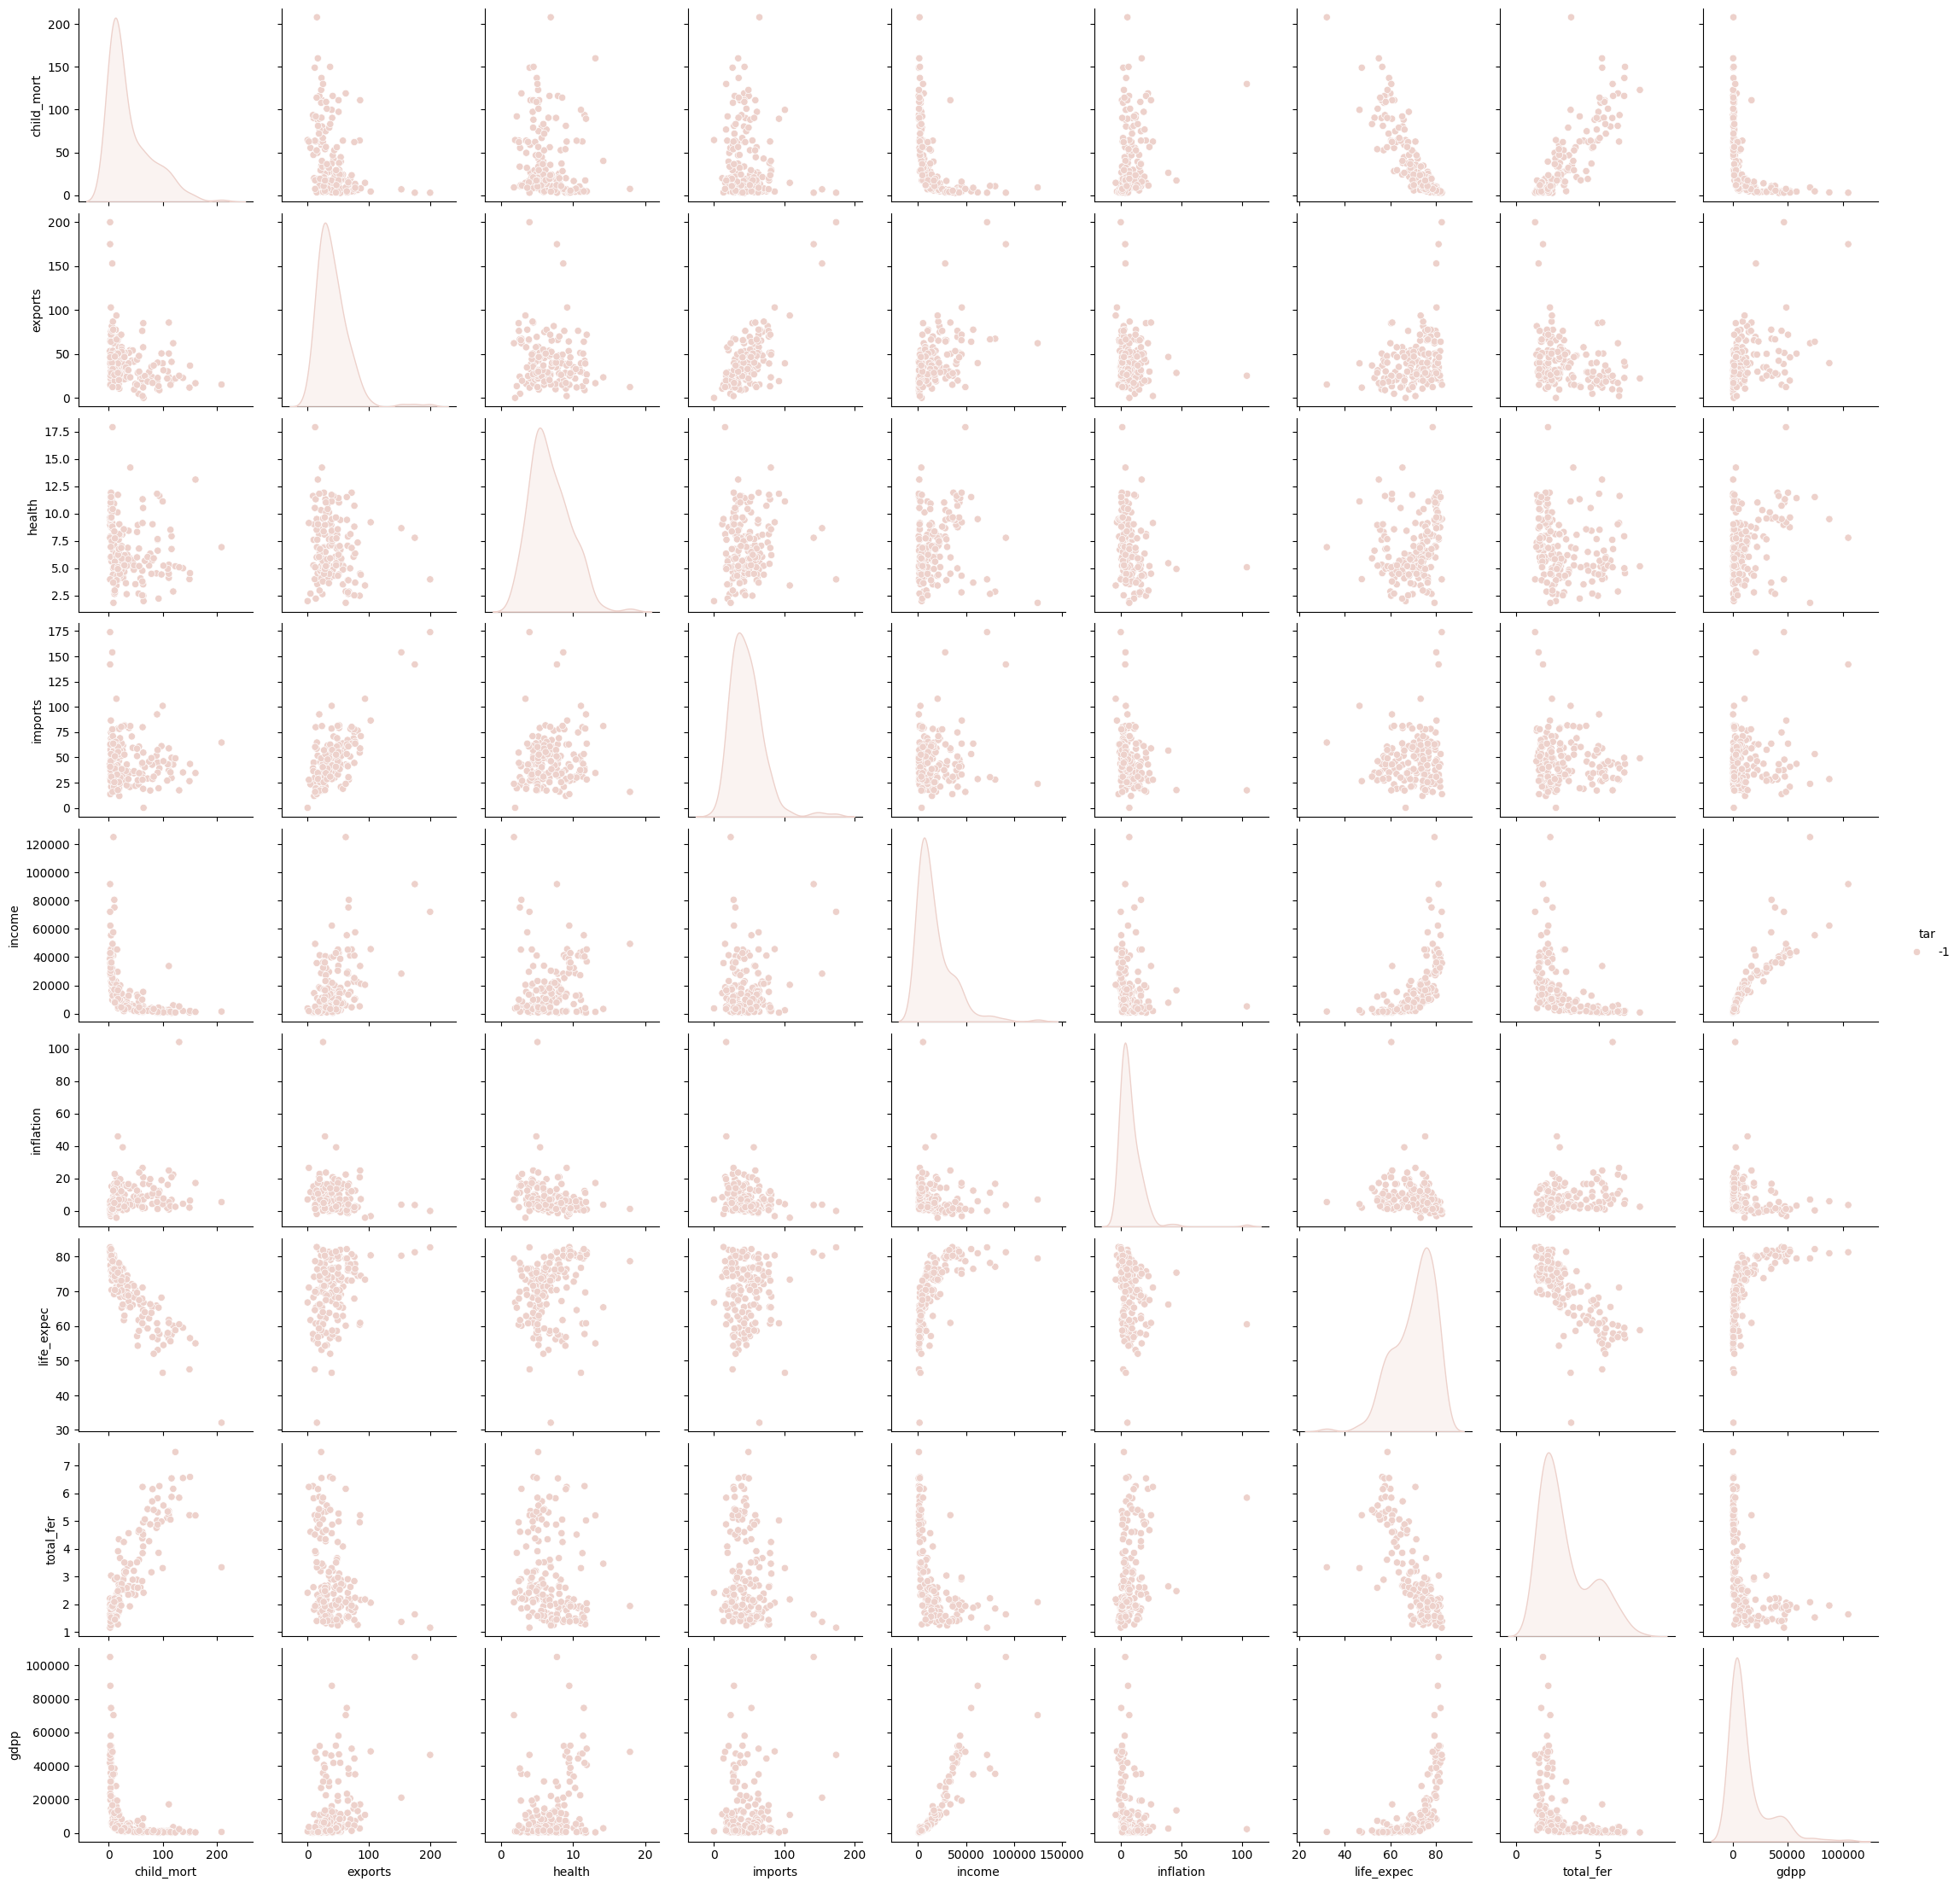

In [35]:
sns.pairplot(x, hue='tar')
plt.show()